# Librerías y carga de datos

In [50]:
import river
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from scipy import stats as spstats
# import labelencoder
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
# PCA
from sklearn.decomposition import PCA
import plotly.express as px
# math y river
import math
from river import stats
from river import cluster
from river import preprocessing as river_prep
from river import anomaly

In [51]:

# Carga de datos
df = pd.read_csv('sensor.csv')

# Limpieza inicial
df = df.drop(columns=['Unnamed: 0'], errors='ignore') # Eliminar columna de índice si existe
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Mapear el estado real de la máquina para evaluación futura
# Asumimos que "NORMAL" es 0 (no anomalía) y "BROKEN" o "RECOVERING" es 1 (anomalía)
if 'machine_status' in df.columns:
    df['is_anomaly_real'] = df['machine_status'].apply(lambda x: 0 if x == 'NORMAL' else 1)

df.isna().sum()


timestamp               0
sensor_00           10208
sensor_01             369
sensor_02              19
sensor_03              19
sensor_04              19
sensor_05              19
sensor_06            4798
sensor_07            5451
sensor_08            5107
sensor_09            4595
sensor_10              19
sensor_11              19
sensor_12              19
sensor_13              19
sensor_14              21
sensor_15          220320
sensor_16              31
sensor_17              46
sensor_18              46
sensor_19              16
sensor_20              16
sensor_21              16
sensor_22              41
sensor_23              16
sensor_24              16
sensor_25              36
sensor_26              20
sensor_27              16
sensor_28              16
sensor_29              72
sensor_30             261
sensor_31              16
sensor_32              68
sensor_33              16
sensor_34              16
sensor_35              16
sensor_36              16
sensor_37   

In [52]:
df = df.drop_duplicates()
df.drop(columns=['sensor_15'], inplace=True, errors='ignore')
df.shape

(220320, 54)

In [53]:
numeric_columns = df.filter(regex='sensor').columns
df[numeric_columns] = df[numeric_columns].fillna(method='ffill').fillna(0)

df.isna().sum()


/var/folders/80/6r8bxtmd43bgpqvzbwvlm7nm0000gn/T/ipykernel_4920/210784236.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_columns] = df[numeric_columns].fillna(method='ffill').fillna(0)


timestamp          0
sensor_00          0
sensor_01          0
sensor_02          0
sensor_03          0
sensor_04          0
sensor_05          0
sensor_06          0
sensor_07          0
sensor_08          0
sensor_09          0
sensor_10          0
sensor_11          0
sensor_12          0
sensor_13          0
sensor_14          0
sensor_16          0
sensor_17          0
sensor_18          0
sensor_19          0
sensor_20          0
sensor_21          0
sensor_22          0
sensor_23          0
sensor_24          0
sensor_25          0
sensor_26          0
sensor_27          0
sensor_28          0
sensor_29          0
sensor_30          0
sensor_31          0
sensor_32          0
sensor_33          0
sensor_34          0
sensor_35          0
sensor_36          0
sensor_37          0
sensor_38          0
sensor_39          0
sensor_40          0
sensor_41          0
sensor_42          0
sensor_43          0
sensor_44          0
sensor_45          0
sensor_46          0
sensor_47    

In [54]:
df_offline = df[numeric_columns].copy()

# Detección de anomalías con full dataset (offline)

En el análisis offline procesamos todo el conjunto de datos a la vez. Es computacionalmente rápido cuando los datos caben en memoria, pero no es capaz de adaptarse de forma nativa a cambios de concepto (Concept Drift), como fluctuaciones estacionales en la temperatura de la bomba.

### Rango Intercuartil (IQR)

El IQR es un método estadístico no paramétrico. Calcula la dispersión central de los datos ($IQR = Q3 - Q1$) y marca como anomalía cualquier punto que se aleje en un factor (usualmente 1.5) de los cuartiles. Limitación: Evalúa cada sensor de manera independiente (univariante) y no detecta relaciones complejas.

In [55]:
def iqr_offline(df_data, factor=1.5):
    anomalies = pd.DataFrame(index=df_data.index)
    for col in df_data.columns:
        Q1 = df_data[col].quantile(0.25)
        Q3 = df_data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - (factor * IQR)
        upper_bound = Q3 + (factor * IQR)
        
        # Guardar True donde hay anomalía
        anomalies[col] = (df_data[col] < lower_bound) | (df_data[col] > upper_bound)
    
    # Si cualquier sensor da anomalía, marcamos la fila como anomalía global
    return anomalies.any(axis=1).astype(int)

df['anomaly_iqr_batch'] = iqr_offline(df_offline, factor=1.5)
print(f"Anomalías detectadas por IQR (Offline): {df['anomaly_iqr_batch'].sum()}")

Anomalías detectadas por IQR (Offline): 162214


### Z-Score (Media y Desviación Estándar)

El método Z-Score asume que los datos se distribuyen de forma normal (Gaussiana). Calcula a cuántas desviaciones estándar ($\sigma$) se encuentra un valor respecto a la media ($\mu$). Valores más allá de un umbral k (por ejemplo, 3 desviaciones) se consideran anómalos.

In [56]:
def zscore_offline(df_data, k=3):
    anomalies = pd.DataFrame(index=df_data.index)
    for col in df_data.columns:
        mean = df_data[col].mean()
        std = df_data[col].std()
        
        if std == 0: # Evitar divisiones por cero
            anomalies[col] = False
            continue
            
        z_scores = np.abs((df_data[col] - mean) / std)
        anomalies[col] = z_scores > k
        
    return anomalies.any(axis=1).astype(int)

df['anomaly_zscore_batch'] = zscore_offline(df_offline, k=3)
print(f"Anomalías detectadas por Z-Score (Offline): {df['anomaly_zscore_batch'].sum()}")

Anomalías detectadas por Z-Score (Offline): 65029


### K-Means Clustering (Experimentos con n_clusters)

K-Means agrupa los datos en $K$ clústeres. La premisa para la detección de anomalías es que las observaciones normales estarán muy cerca de los centroides de su clúster, mientras que las anomalías estarán lejos.
Realizaremos experimentos con diferentes números de clústeres para ver cómo afecta a las detecciones. Usaremos el percentil 99 de las distancias como umbral para marcar el 1% de datos más extremos como anomalías.

In [57]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Escalar los datos offline
scaler_offline = StandardScaler()
data_scaled = scaler_offline.fit_transform(df_offline)

# Experimentos con distintos K
experimentos_k = [1, 2, 3, 4, 5]

for k in experimentos_k:
    print(f"\n--- Entrenando K-Means con {k} clusters ---")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(data_scaled)
    
    # Calcular distancias al centroide
    distances = []
    for i, point in enumerate(data_scaled):
        centroid = kmeans.cluster_centers_[clusters[i]]
        dist = np.linalg.norm(point - centroid)
        distances.append(dist)
        
    # Definir umbral como el percentil 95 (el 5% más lejano)
    threshold = np.percentile(distances, 95)
    anomalias = (np.array(distances) > threshold).astype(int)
    
    df[f'anomaly_kmeans_batch_{k}'] = anomalias
    print(f"Umbral de distancia: {threshold:.2f}")
    print(f"Anomalías detectadas: {sum(anomalias)}")


--- Entrenando K-Means con 1 clusters ---
Umbral de distancia: 13.39
Anomalías detectadas: 11016

--- Entrenando K-Means con 2 clusters ---
Umbral de distancia: 12.33
Anomalías detectadas: 11016

--- Entrenando K-Means con 3 clusters ---
Umbral de distancia: 7.72
Anomalías detectadas: 11016

--- Entrenando K-Means con 4 clusters ---
Umbral de distancia: 7.54
Anomalías detectadas: 11016

--- Entrenando K-Means con 5 clusters ---
Umbral de distancia: 7.54
Anomalías detectadas: 11016


### Isolation Forest (Experimentos con contamination)

A diferencia de aislar lo "normal", Isolation Forest se centra explícitamente en aislar las anomalías. Crea árboles aleatorios; las anomalías, al ser diferentes y escasas, requieren menos cortes (profundidad del árbol) para ser aisladas. Experimentaremos con la tasa esperada de ruido (contamination).

In [58]:
from sklearn.ensemble import IsolationForest

# Experimentos con distinta contaminación
tasas_ruido = [0.01, 0.05, 0.10] # Esperamos un 1%, 5% y 10% de anomalías

for contaminacion in tasas_ruido:
    print(f"\n--- Entrenando Isolation Forest con contamination={contaminacion} ---")
    iso_forest = IsolationForest(contamination=contaminacion, random_state=42, n_jobs=-1)
    
    # predict() devuelve 1 para normal y -1 para anomalía. Lo convertimos a 0 y 1.
    predicciones = iso_forest.fit_predict(data_scaled)
    anomalias = np.where(predicciones == -1, 1, 0)
    
    df[f'anomaly_iforest_batch_{contaminacion}'] = anomalias
    print(f"Anomalías detectadas: {sum(anomalias)}")


--- Entrenando Isolation Forest con contamination=0.01 ---
Anomalías detectadas: 2204

--- Entrenando Isolation Forest con contamination=0.05 ---
Anomalías detectadas: 11016

--- Entrenando Isolation Forest con contamination=0.1 ---
Anomalías detectadas: 22032


# Análisis Incremental (Streaming) con river

En la realidad industrial, los datos llegan uno a uno. Los métodos online se adaptan iterativamente, ajustando sus métricas internas y olvidando patrones obsoletos (Concept Drift). Esto permite que el umbral de lo que es "anómalo" varíe dinámicamente según el contexto (verano vs. invierno, por ejemplo).

In [59]:


class AdaptiveZScore:
    def __init__(self, k=3.0):
        self.mean = stats.Mean()
        self.variance = stats.Var()
        self.k = k
        self.count = 0
        
    def update_and_predict(self, value):
        self.count += 1
        
        # Calcular si es anomalía antes de actualizar (para no contaminar la estadística)
        is_anom = False
        if self.count > 2:
            current_mean = self.mean.get()
            current_std = math.sqrt(self.variance.get())
            if current_std > 0:
                z_score = abs(value - current_mean) / current_std
                is_anom = z_score > self.k
                
        # Actualizar estado
        self.mean.update(value)
        self.variance.update(value)
        return int(is_anom)

# Lo aplicamos al sensor_00 como ejemplo ilustrativo (multivariante requeriría un detector por sensor)
z_detector = AdaptiveZScore(k=3.0)
df['anomaly_zscore_online_s00'] = df['sensor_00'].apply(z_detector.update_and_predict)
print(f"Anomalías Z-Score Online (Solo Sensor 00): {df['anomaly_zscore_online_s00'].sum()}")

Anomalías Z-Score Online (Solo Sensor 00): 12849


In [60]:
from river import cluster
from river import preprocessing as river_prep
n_clusters = [1, 2, 3, 4, 5]

for k in n_clusters:
    print(f"\n--- Entrenando K-Means Incremental con {k} clusters ---")
    # Escalador incremental
    scaler_river = river_prep.StandardScaler()
    # Modelo incremental
    kmeans_online = cluster.KMeans(n_clusters=k, halflife=0.5, seed=42)

    threshold_online = 2.5
    anomalies_kmeans_online = []
    dists = []
    for i, row in df_offline.iterrows():
        # Convertir fila a diccionario para River
        x = row.to_dict()
        
        # Estandarizar
        scaler_river.learn_one(x)
        x_scaled = scaler_river.transform_one(x)
        
        # Predecir
        cluster_id = kmeans_online.predict_one(x_scaled)
        centroids = kmeans_online.centers
        
        is_anom = 0
        if centroids:
            centroid = centroids[cluster_id]
            # Calcular distancia euclídea manual
            dist = math.sqrt(sum((x_scaled[f] - centroid[f])**2 for f in x_scaled))
            if dist > threshold_online:
                is_anom = 1
                
        anomalies_kmeans_online.append(is_anom)
        dists.append(dist)
        # Aprender
        kmeans_online.learn_one(x_scaled)

    df[f'anomaly_kmeans_online_{k}'] = anomalies_kmeans_online
    print(f"Anomalías detectadas por K-Means Incremental con {k} clusters: {sum(anomalies_kmeans_online)}")


--- Entrenando K-Means Incremental con 1 clusters ---
Anomalías detectadas por K-Means Incremental con 1 clusters: 13998

--- Entrenando K-Means Incremental con 2 clusters ---
Anomalías detectadas por K-Means Incremental con 2 clusters: 13992

--- Entrenando K-Means Incremental con 3 clusters ---
Anomalías detectadas por K-Means Incremental con 3 clusters: 13983

--- Entrenando K-Means Incremental con 4 clusters ---
Anomalías detectadas por K-Means Incremental con 4 clusters: 13983

--- Entrenando K-Means Incremental con 5 clusters ---
Anomalías detectadas por K-Means Incremental con 5 clusters: 13977


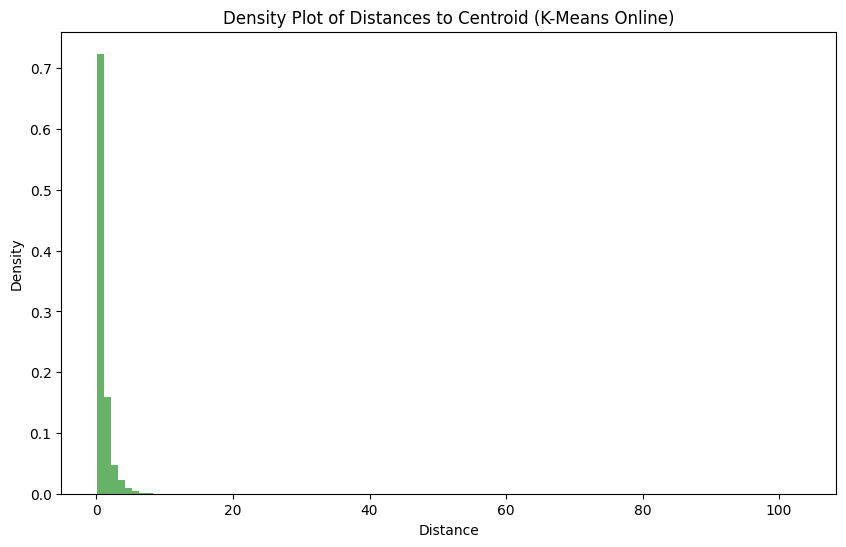

Distancia media al centroide: 0.98
Distancia máxima al centroide: 103.21
Distancia al centroide en el percentil 95: 2.81


In [61]:
# density plot of distnaces
plt.figure(figsize=(10, 6))
plt.hist(dists, bins=100, density=True, alpha=0.6, color='g')
plt.title('Density Plot of Distances to Centroid (K-Means Online)')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.show()
print(f"Distancia media al centroide: {np.mean(dists):.2f}")
print(f"Distancia máxima al centroide: {np.max(dists):.2f}")
# 90 percentil
print(f"Distancia al centroide en el percentil 95: {np.percentile(dists, 95):.2f}")

In [62]:

experimentos_trees = [5, 10, 30]
umbral_hst = 0.9 # Puntuaciones > 0.95 son anomalías

for n_trees in experimentos_trees:
    print(f"\n--- Entrenando HST con n_trees={n_trees} ---")
    scaler_hst = river_prep.StandardScaler()
    hst = anomaly.HalfSpaceTrees(n_trees=n_trees, height=8, window_size=250, seed=42)
    
    anomalies_hst = []
    
    for i, row in df_offline.iterrows():
        x = row.to_dict()
        
        scaler_hst.learn_one(x)
        x_scaled = scaler_hst.transform_one(x)
        
        # Puntuar
        if hst.n_trees > 0:
            score = hst.score_one(x_scaled)
        else:
            score = 0
            
        anomalies_hst.append(1 if score > umbral_hst else 0)
        
        # Entrenar
        hst.learn_one(x_scaled)
        
    df[f'anomaly_hst_{n_trees}'] = anomalies_hst
    print(f"Anomalías detectadas: {sum(anomalies_hst)}")


--- Entrenando HST con n_trees=5 ---
Anomalías detectadas: 12094

--- Entrenando HST con n_trees=10 ---
Anomalías detectadas: 8624

--- Entrenando HST con n_trees=30 ---
Anomalías detectadas: 6924


# Evaluación de Modelos (Métricas F1, Precision, Recall)

Finalmente, cruzaremos las anomalías detectadas por todos los modelos contra la variable real de estado de la máquina is_anomaly_real. Dado que los fallos son eventos críticos y poco frecuentes, el F1-Score y el Recall (poder detectar todos los fallos para evitar desastres en la bomba) son nuestras métricas principales.

In [63]:
# Mostrar tabla resumen de métricas
resultados = []

columnas_modelos = [col for col in df.columns if 'anomaly_' in col and col != 'is_anomaly_real']

for col in columnas_modelos:
    y_true = df['is_anomaly_real'].values
    y_pred = df[col].values
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    resultados.append({
        'Modelo': col,
        'Anomalías Detectadas': y_pred.sum(),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='F1-Score', ascending=False)
display(df_resultados)

,Modelo,Anomalías Detectadas,Precision,Recall,F1-Score
10,anomaly_zscore_online_s00,12849,0.8614,0.7642,0.8099
3,anomaly_kmeans_batch_2,11016,0.8859,0.6738,0.7654
9,anomaly_iforest_batch_0.1,22032,0.5656,0.8604,0.6826
2,anomaly_kmeans_batch_1,11016,0.7840,0.5962,0.6773
8,anomaly_iforest_batch_0.05,11016,0.7439,0.5658,0.6427
1,anomaly_zscore_batch,65029,0.2221,0.9972,0.3633
5,anomaly_kmeans_batch_4,11016,0.3284,0.2498,0.2838
6,anomaly_kmeans_batch_5,11016,0.3273,0.2490,0.2828
4,anomaly_kmeans_batch_3,11016,0.2891,0.2199,0.2498
7,anomaly_iforest_batch_0.01,2204,0.6538,0.0995,0.1727
